# Smart Football Scouting System: Rekomendasi Pemain Pengganti Berbasis Unsupervised Machine Learning dan Dashboard Interaktif Streamlit

## 🎬 Prolog: Mencari "Kembaran" Pemain yang Pergi

Bayangkan kamu adalah direktur olahraga sebuah klub. Gelandang andalan tim baru saja dijual, anggaran terbatas, dan bursa transfer tinggal beberapa pekan lagi.

Pertanyaan yang muncul **bukan** *"siapa pemain terbaik di dunia?"*, melainkan:

> **"Siapa pemain lain yang gaya mainnya paling mirip, dan bisa menggantikannya?"**

Untuk menjawabnya, proyek ini memakai pendekatan *unsupervised machine learning* (*Nearest Neighbors*) yang akan disajikan lewat dashboard Streamlit. Namun model sebaik-baiknya hanya sebaik data yang disuapkan kepadanya.

**Notebook ini adalah Bab 1 dari cerita tersebut.** Belum ada model di sini. Tugas kita adalah memeriksa bahan mentah, menemukan masalahnya, lalu membersihkannya sampai layak dibandingkan.

| Babak | Pertanyaan yang dijawab | Hasil |
|---|---|---|
| 📦 Membuka data | Apa isi dataset ini? | Gambaran awal 2.839 baris × 53 kolom |
| 🕳️ Mencari lubang | Di mana data kosong? | Kiper ternyata "tamu" dari dunia lain |
| ⏱️ Menimbang menit | Siapa yang terlalu sedikit tampil? | Ambang batas 900 menit |
| 🧹 Menyaring | Siapa yang layak dibandingkan? | Dataset outfield yang bersih |
| ⚖️ Menyamakan panggung | Bagaimana membandingkan secara adil? | Fitur *per 90 menit* |
| 💾 Serah terima | Apa yang dibawa ke Bab 2? | `players_cleaned.parquet` |

### 📦 Membuka Peti Data

Setiap detektif memulai dari barang bukti. Kita siapkan peralatan (*pandas* untuk mengolah tabel, *matplotlib* dan *seaborn* untuk menggambar), lalu membuka dataset statistik pemain musim 2025/2026.

Dua hal yang ingin kita ketahui sejak awal: **seberapa besar** datanya dan **apa saja** yang dicatat di dalamnya.

In [25]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("/Users/rachman/Coding Related/DQLab/Projek Akhir/data/raw/players_data_light-2025_2026.csv")
print("Total baris & kolom:", df.shape)
print("\nDaftar kolom:")
print(df.columns.tolist())

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"

Total baris & kolom: (2839, 53)

Daftar kolom:
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs', 'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm']


**Temuan:** peti ini berisi **2.839 baris dan 53 kolom**. Satu baris mewakili satu pemain pada satu musim.

Daftar kolomnya menyimpan dua dunia yang berbeda sekaligus. Ada statistik pemain lapangan (`Gls`, `Ast`, `Crs`, `TklW`, `Int`) dan ada statistik khusus kiper (`Saves`, `Save%`, `CS`, `GA90`). Ingat detail ini, karena akan menjadi sumber masalah di babak berikutnya.

Sebelum menyimpulkan apa pun, mari intip lima baris pertama untuk merasakan seperti apa wujud datanya.

In [11]:
print("Ukuran dataset awal:", df.shape)
df.head()

Ukuran dataset awal: (2839, 53)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Yang tertangkap mata:** hampir semua kolom kiper (`Save%`, `W`, `D`, `L`, `CS`) bernilai `NaN` untuk pemain-pemain ini. Pemain lapangan memang tidak punya statistik penyelamatan.

Ada juga dua baris yang mencurigakan. **Jerome Abbey** (usia 15 tahun) hanya tampil **1 laga** dengan total **0,2 satuan 90 menit**, dan **Zach Abbott** hanya tampil 3 laga. Pemain yang hanya muncul sekejap seperti ini bisa menghasilkan angka yang menyesatkan. Kita akan kembali ke mereka nanti.

Untuk saat ini, pertanyaan pertama kita: **seberapa banyak data yang kosong, dan di mana letaknya?**

### 1. Eksplorasi Nilai Kosong (Missing Values) pada Dataset Mentah
Sebelum memodelkan karakteristik pemain, kita perlu memeriksa kelengkapan data. 
Apakah seluruh kolom memiliki data yang terisi penuh, atau terdapat kolom spesifik yang dominan bernilai kosong (*null/NaN*)?

/var/folders/_z/xffhjzpj1zn8q00zr583d4bc0000gp/T/ipykernel_62103/2435464302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing.values, y=top_missing.index, palette="Reds_r")


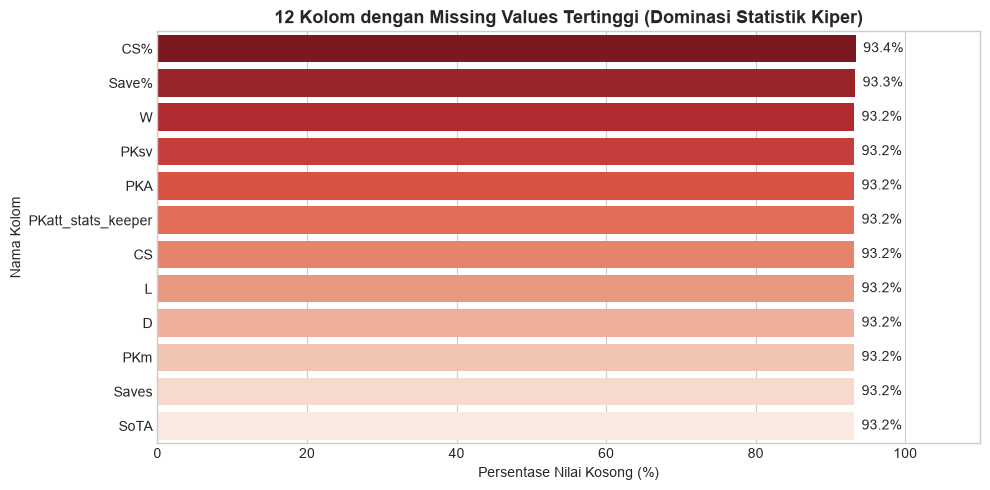

In [18]:
# Cek persentase missing values untuk 15 kolom teratas
missing_pct = (df.isnull().sum() / len(df)) * 100
top_missing = missing_pct[missing_pct > 0].sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_missing.values, y=top_missing.index, palette="Reds_r")
plt.title(
    "12 Kolom dengan Missing Values Tertinggi (Dominasi Statistik Kiper)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Persentase Nilai Kosong (%)")
plt.ylabel("Nama Kolom")

for index, value in enumerate(top_missing.values):
    plt.text(value + 1, index, f"{value:.1f}%", va="center", fontsize=10)

plt.xlim(0, 110)
plt.tight_layout()
plt.show()

> **💡 Insight:**
> Dari grafik di atas, kolom statistik khusus kiper (`Save%`, `CS%`, `GA90`) memiliki tingkat kekosongan mencapai **~95%**. 
> Hal ini wajar karena mayoritas data diisi oleh pemain non-kiper (*outfield players*). 
> 
> **Keputusan:** Penjaga gawang (`Pos == 'GK'`) dipisahkan/dieliminasi dari analisis ini agar tidak merusak representasi pola gaya main pemain lapangan.

---
### ⏱️ Interlude: Kiper Sudah Keluar, Tapi Masih Ada Tamu Lain

Persoalan kiper sudah selesai di atas kertas. Tapi ingat Jerome Abbey, remaja 15 tahun yang hanya tampil 0,2 satuan 90 menit? Pemain-pemain seperti dia adalah masalah **kedua**.

Masalahnya tidak terlihat sebagai nilai kosong, jadi tidak akan tertangkap oleh grafik sebelumnya. Angkanya terisi lengkap, hanya saja **dibangun dari terlalu sedikit bukti**. Untuk menemukannya, kita harus melihat seberapa lama setiap pemain benar-benar berada di lapangan.

### 2. Distribusi Waktu Bermain & Potensi Bias Sampel
Menit bermain menentukan kestabilan performa seorang pemain. 
Visualisasi ini bertujuan untuk melihat sebaran menit bermain seluruh pemain dan mengidentifikasi pemain cadangan yang jarang tampil.

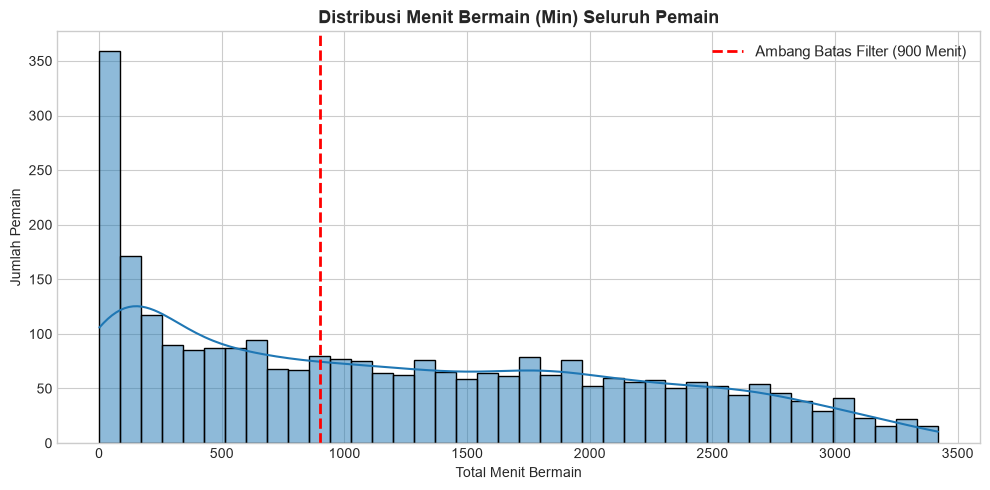

Jumlah pemain dengan menit < 900 : 1261 pemain (Dibuang)
Jumlah pemain dengan menit >= 900: 1578 pemain (Dipertahankan)


In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Min"].dropna(), bins=40, kde=True, color="#1f77b4")
plt.axvline(
    900,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ambang Batas Filter (900 Menit)",
)

plt.title(
    "Distribusi Menit Bermain (Min) Seluruh Pemain",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Total Menit Bermain")
plt.ylabel("Jumlah Pemain")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(
    f"Jumlah pemain dengan menit < 900 : {(df['Min'] < 900).sum()} pemain (Dibuang)"
)
print(
    f"Jumlah pemain dengan menit >= 900: {(df['Min'] >= 900).sum()} pemain (Dipertahankan)"
)

> **💡 Insight :**
> Distribusi data condong ke kiri (*right-skewed*) dengan penumpukan pemain di bawah 400 menit (pemain akademi atau cadangan minim menit tampil). 
> Jika dipertahankan, pemain yang hanya bermain 10 menit namun mencetak 1 gol akan terhitung memiliki rata-rata 9 gol per laga (anomali fatal).
> 
> **Keputusan:** Menetapkan batas ambang minimal **900 menit bermain** (setara 10 laga penuh) untuk memastikan sampel yang masuk ke model memiliki performa yang konsisten.

---
### 🧹 Saatnya Eksekusi: Empat Filter

Dua keputusan sudah kita ambil lewat visualisasi di atas. Kini keduanya dijalankan, ditambah dua langkah pengaman, dalam satu cell pembersihan:

1. **Buang baris tanpa nama atau duplikat**, supaya tidak ada pemain yang terhitung dua kali.
2. **Buang kiper** (`Pos != 'GK'`), karena metrik mereka hidup di dunia yang berbeda.
3. **Buang pemain dengan menit < 900**, agar angka yang tersisa punya cukup bukti.
4. **Pastikan `90s > 0`**, sebagai pengaman agar tidak terjadi pembagian dengan nol pada langkah berikutnya.

In [12]:
# Cell 3: Data Cleaning & Filtering
# Kita akan membuang baris yang duplikat atau memiliki nilai NaN di kolom 'Player'
df = df.dropna(subset=['Player']).drop_duplicates()

# Filter 1: Buang Goalkeepers (Karena metrik rekomendasinya berbeda total)
df = df[df['Pos'] != 'GK'].copy()

# Filter 2: Buang pemain yang bermain kurang dari 900 menit
df = df[df['Min'] >= 900].copy()

# Filter 3: Hapus pemain yang menit (90s) nya 0 untuk menghindari division by zero
df = df[df['90s'] > 0].copy()

print("Ukuran dataset setelah filter (Outfield, Min >= 900):", df.shape)

Ukuran dataset setelah filter (Outfield, Min >= 900): (1464, 53)


**Hasil penyaringan:** dari **2.839** pemain, tersisa **1.464** pemain lapangan yang layak dibandingkan, atau sekitar **52%** dari data awal.

Sebelumnya ada **1.578** pemain yang lolos ambang 900 menit. Selisih 114 pemain adalah mereka yang gugur pada filter berikutnya, terutama para kiper yang tampil penuh musim ini. Data ini kecil di jumlah, tapi jauh lebih bersih dan konsisten.

Masih ada satu masalah tersisa: **pemain yang bermain 3.000 menit dan 1.000 menit sama-sama lolos, padahal angka kumulatif mereka tidak bisa dibandingkan secara langsung.**

---
### ⚖️ Menyamakan Panggung: Mengapa Harus "Per 90 Menit"?

Bayangkan dua gelandang bertahan. **Pemain A** bermain 3.000 menit dan mencatat 90 tekel sukses. **Pemain B** bermain 1.000 menit dan mencatat 45 tekel sukses. Kalau hanya melihat total, A tampak dua kali lebih tangguh. Padahal per pertandingan, B justru jauh lebih agresif.

Itulah alasan kita mengubah metrik kumulatif menjadi **laju per 90 menit** (satu pertandingan penuh), dengan rumus sederhana:

$$\text{metrik\_per90} = \frac{\text{total metrik}}{\text{90s}}$$

Cell berikut menerapkannya pada tujuh metrik: `Gls`, `Ast`, `Crs`, `TklW`, `Int`, `Fld`, dan `Fls`.

In [23]:
# Cell 4: Feature Engineering (Normalisasi ke Per 90 Menit)
# Metrik kumulatif ini perlu diubah jadi rata-rata per 90 menit agar fair
metrics_to_normalize = [
    'Gls', 'Ast', 'Crs', 'TklW', 'Int', 'Fld', 'Fls'
]

for col in metrics_to_normalize:
    new_col_name = f"{col}_per90"
    df[new_col_name] = df[col] / df['90s']

# Tampilkan kolom baru yang sudah di-generate
print("Kolom per90 berhasil dibuat!")
df[['Player', 'Pos', '90s', 'Gls_per90', 'Ast_per90', 'TklW_per90']].head()

Kolom per90 berhasil dibuat!


,Player,Pos,90s,Gls_per90,Ast_per90,TklW_per90
0,Brenden Aaronson,"MF,FW",27.2,0.147059,0.183824,0.992647
1,Jerome Abbey,MF,0.2,0.000000,0.000000,0.000000
2,Zach Abbott,DF,1.8,0.000000,0.000000,2.222222
3,Jones El-Abdellaoui,"MF,FW",7.6,0.263158,0.000000,0.394737
4,Himad Abdelli,MF,1.5,0.000000,0.000000,0.666667


Tujuh kolom baru berakhiran `_per90` kini hadir di dataset. Tapi apakah transformasi ini benar-benar mengubah gambaran datanya, atau hanya kosmetik? **Mari buktikan dengan membandingkan distribusi sebelum dan sesudahnya.**

### 3. Evaluasi Transformasi Fitur: Total Akumulatif vs Laju Intensitas (Per 90 Menit)
Salah satu bias terbesar dalam data performa sepak bola adalah perbedaan total waktu bermain antar-pemain. 
Visualisasi di bawah membandingkan distribusi jumlah tekel sukses (*Tackles Won*) sebelum dan sesudah dinormalisasi ke satuan 90 menit bermain untuk membuktikan urgensi standardisasi metrik.

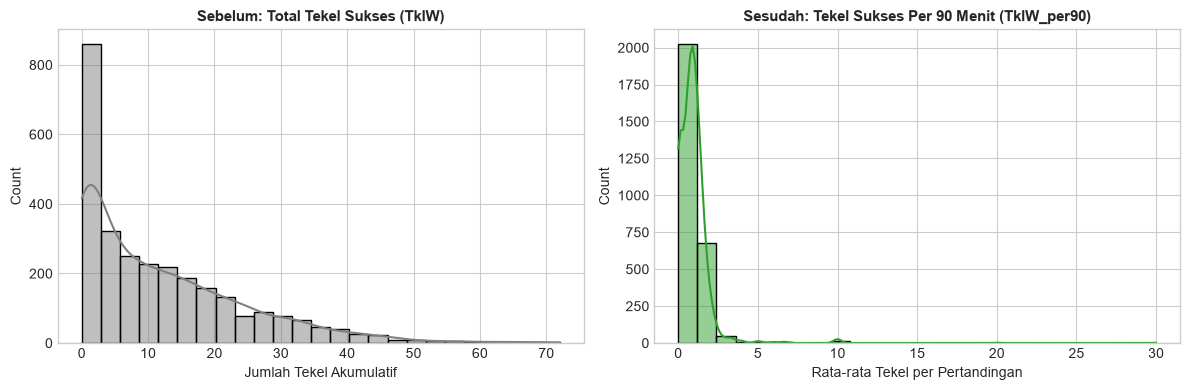

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sebelum normalisasi (Total Tackles Won)
sns.histplot(
    df["TklW"], bins=25, kde=True, ax=axes[0], color="gray", edgecolor="black"
)
axes[0].set_title(
    "Sebelum: Total Tekel Sukses (TklW)", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("Jumlah Tekel Akumulatif")

# Sesudah normalisasi (Tackles Won per 90)
sns.histplot(
    df["TklW_per90"],
    bins=25,
    kde=True,
    ax=axes[1],
    color="#2ca02c",
    edgecolor="black",
)
axes[1].set_title(
    "Sesudah: Tekel Sukses Per 90 Menit (TklW_per90)",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Rata-rata Tekel per Pertandingan")

plt.tight_layout()
plt.show()

> **💡 Insight & Justifikasi Metodologi (Feature Engineering):**
> 
> * **Sebelum Normalisasi (`TklW`):** 
>   Grafik di sebelah kiri sangat bias terhadap durasi bermain di lapangan. Pemain inti yang bermain 3.000 menit otomatis mengoleksi angka tekel kumulatif yang jauh lebih besar dibanding pemain dengan 1.000 menit, meskipun pemain kedua tersebut mungkin memiliki agresivitas dan tingkat keberhasilan tekel yang jauh lebih tinggi setiap kali diturunkan.
> 
> * **Sesudah Normalisasi (`TklW_per90`):** 
>   Grafik di sebelah kanan bertransformasi menjadi **laju intensitas riil per pertandingan**. Distribusi menjadi terstandarisasi, memungkinkan model *Machine Learning* membandingkan kapasitas bertahan pemain secara objektif (*fair comparison*) tanpa dipengaruhi oleh status apakah pemain tersebut starter reguler atau pemain rotasi taktis.
> 
> **Keputusan:** Seluruh fitur volume defensif dan ofensif (`Gls`, `Ast`, `Crs`, `TklW`, `Int`, `Fld`, `Fls`) wajib ditransformasikan ke format `_per90` sebelum masuk ke tahap *StandardScaler* dan pemodelan *Nearest Neighbors*.

---
### 💾 Serah Terima: Menyimpan Data Bersih

Semua pekerjaan pembersihan sudah selesai. Agar Bab 2 tidak perlu mengulang dari nol, hasilnya disimpan dalam format **Parquet**. Formatnya lebih ringan dibanding CSV, dan tipe datanya terjaga.

Indeks juga diatur ulang dari 0 supaya urutannya rapi setelah banyak baris dibuang.

In [26]:
# Cell 5: Simpan Data Bersih untuk Modeling
from pathlib import Path

# 1. Reset index secara bersih agar index urut dari 0 tanpa anomali
df = df.reset_index(drop=True)

# 2. Buat folder processed jika belum ada
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# 3. Simpan sebagai parquet
save_path = processed_dir / "players_cleaned.parquet"
df.to_parquet(save_path, index=False)

print(f"Data bersih berhasil disimpan ke {save_path}")

Data bersih berhasil disimpan ke ../data/processed/players_cleaned.parquet


---
## 🏁 Epilog: Dari Data Mentah ke Siap Pakai

Perjalanan Bab 1 kalau diringkas:

- Kita mulai dari **2.839 pemain × 53 kolom** yang bercampur antara pemain lapangan dan kiper.
- Kita menemukan bahwa kolom kiper nyaris kosong untuk pemain lapangan, lalu **memisahkan kiper** dari analisis.
- Kita menyadari bahwa pemain dengan menit tampil minim menghasilkan angka menyesatkan, lalu menetapkan **ambang 900 menit**.
- Kita menyamakan skala dengan **normalisasi per 90 menit** agar pemain starter dan pemain rotasi bisa dibandingkan secara adil.
- Hasilnya adalah **1.464 pemain lapangan** dengan fitur yang siap diproses.

**Selanjutnya (Bab 2):** data bersih ini akan diskalakan dengan `StandardScaler`, lalu *Nearest Neighbors* mencari pemain dengan profil permainan paling mirip. Dari situ lahirlah rekomendasi pemain pengganti yang akan tampil di dashboard Streamlit.